In [3]:
import numpy as np
import pandas as pd
import time
import seaborn as sns
import hypernetx as hnx
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import time


expresson_data.csv, methylation_data.csv is non-negativate sparse data.

ATAC_lsi.csv is standardized non-sparse data.



In [4]:
df = pd.read_csv('./data/sci_CAR/RNA_pca.csv').dropna(axis=1, how='all').set_index('Unnamed: 0')
df.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_41,PC_42,PC_43,PC_44,PC_45,PC_46,PC_47,PC_48,PC_49,PC_50
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
coRNA-RNA-plate1-001.ACGCTTCTCT,-7.017167,6.967923,-0.890448,-2.346056,-1.416960,1.506067,1.304570,-0.858997,-1.087285,-6.778815,...,0.421661,0.874643,-2.150176,0.240963,0.924930,-0.873113,-1.058278,-0.942198,-1.421278,-1.037981
coRNA-RNA-plate1-001.ACGTTGAATG,6.305976,-0.369384,-1.355127,-1.655408,-4.657099,2.963242,0.986717,-0.206425,2.918024,0.126151,...,0.507215,0.073329,-0.326177,0.232422,0.086111,0.251889,0.328241,-0.404705,-1.132548,-0.279805
coRNA-RNA-plate1-001.AGGACTGCGA,5.064980,-0.600983,-0.238661,-1.565617,-4.026646,2.802538,1.202787,-0.209955,3.695962,-0.016300,...,-0.189905,0.207583,-0.287082,0.259737,1.045928,0.353594,-0.530509,0.338505,-0.200046,0.299909
coRNA-RNA-plate1-001.AGGCCGGTAA,6.167741,-0.191367,-1.118713,-1.460923,-4.526852,2.360865,0.912821,-0.240274,2.319247,-0.092466,...,0.285172,0.642185,-0.307905,-1.238700,-0.797882,1.270203,0.263561,-0.023996,-1.078793,0.111626
coRNA-RNA-plate1-001.CATGACTCAA,-17.017403,18.867785,0.207563,-1.291055,1.401379,3.686704,-3.243650,1.398786,1.698218,2.927851,...,2.680566,-0.044568,0.220771,-0.641249,0.782806,-0.290419,-2.359336,1.719087,-2.390894,-1.876154


In [5]:
df.describe()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_41,PC_42,PC_43,PC_44,PC_45,PC_46,PC_47,PC_48,PC_49,PC_50
count,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,...,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03,8.837000e+03
mean,5.364650e-15,-1.913649e-16,1.529311e-15,6.239461e-16,-3.687393e-15,-3.023244e-16,4.727839e-16,4.848447e-16,-1.318649e-15,1.731933e-15,...,7.907873e-16,1.413125e-16,-2.794088e-16,-1.479460e-16,9.791371e-16,-5.330880e-16,9.809462e-17,1.292919e-15,1.041250e-15,7.421421e-16
std,8.963065e+00,7.047403e+00,6.490312e+00,5.373663e+00,4.719561e+00,4.481323e+00,4.040013e+00,3.273504e+00,3.252075e+00,2.922156e+00,...,1.856392e+00,1.852725e+00,1.847473e+00,1.838702e+00,1.835286e+00,1.823236e+00,1.819947e+00,1.817989e+00,1.814643e+00,1.812127e+00
min,-3.575395e+01,-2.632577e+01,-1.420779e+01,-2.325166e+01,-9.152132e+00,-3.557443e+01,-1.840102e+01,-2.806557e+01,-1.171025e+01,-1.812938e+01,...,-1.264876e+01,-1.536002e+01,-1.175152e+01,-1.097858e+01,-1.288979e+01,-1.179065e+01,-1.145420e+01,-1.165489e+01,-9.531790e+00,-1.071229e+01
25%,-5.043446e+00,-6.635454e-01,-1.583239e+00,-1.425587e+00,-2.381135e+00,-6.988793e-01,-1.239406e+00,-5.663314e-01,-1.894978e+00,-5.619524e-01,...,-8.529232e-01,-8.401348e-01,-9.042817e-01,-9.239878e-01,-7.862637e-01,-8.516899e-01,-9.292066e-01,-8.122774e-01,-9.538120e-01,-7.657421e-01
50%,4.953627e+00,-2.050369e-01,-1.009233e+00,-7.019602e-01,-8.066081e-01,9.238779e-01,2.548369e-02,3.049483e-02,-2.315695e-01,-4.364248e-02,...,5.421473e-02,1.034819e-01,-1.081874e-01,-1.605234e-01,-3.100449e-02,9.662220e-02,-4.466977e-02,-2.112904e-02,-1.150663e-01,5.640737e-02
75%,6.090184e+00,1.934295e-01,-2.355223e-01,5.093549e-01,6.049808e-01,2.166456e+00,1.049830e+00,5.656398e-01,1.913780e+00,5.563324e-01,...,8.171954e-01,9.023497e-01,7.683158e-01,7.571932e-01,7.176544e-01,8.861660e-01,9.221941e-01,7.804813e-01,8.191491e-01,8.132806e-01
max,1.041429e+01,2.702953e+01,6.143886e+01,3.088690e+01,2.514284e+01,1.167892e+01,2.613967e+01,3.634668e+01,1.663301e+01,2.470380e+01,...,1.414085e+01,1.266619e+01,1.109005e+01,1.332331e+01,1.243935e+01,1.041255e+01,1.339537e+01,1.295698e+01,1.054818e+01,1.088701e+01


<Axes: xlabel='PC_2', ylabel='Count'>

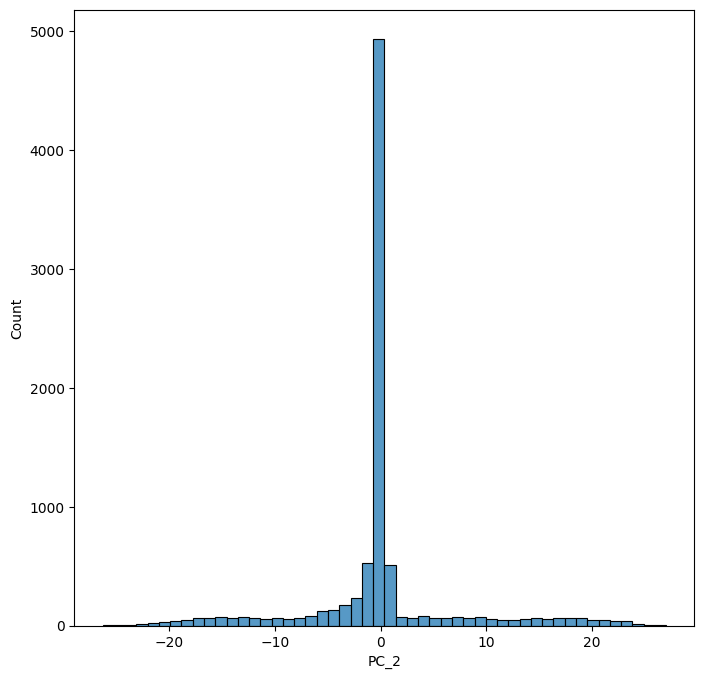

In [12]:
sns.histplot(df.PC_2, bins=50)

In [7]:
mask = np.abs(df) >= 2

In [8]:
nonzeros = (df != 0).astype(int)

<Axes: ylabel='Unnamed: 0'>

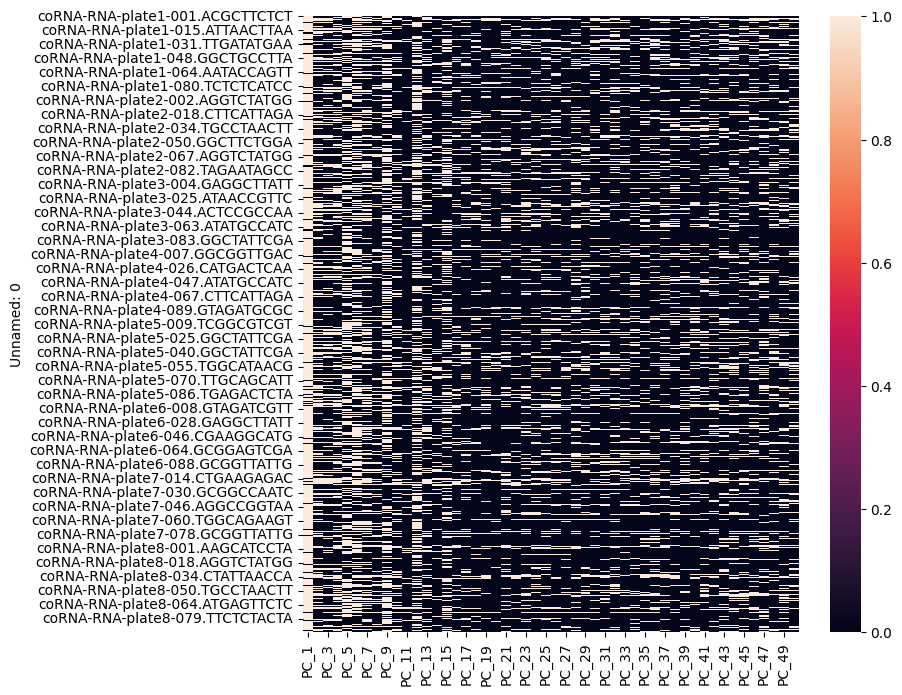

In [9]:
sns.heatmap(mask)